In [ ]:
import torch

print(torch.cuda.is_available())

True


In [ ]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tmdb_movies_clean.csv to tmdb_movies_clean (2).csv


In [ ]:
import pandas as pd

df = pd.read_csv("tmdb_movies_clean.csv")

print(df.shape)
df.head()

(8985, 7)


,id,title,overview,genres,release_date,vote_average,popularity
0,969681,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,Action|Adventure|Science Fiction,2026-07-29,7.865,839.8385
1,1204680,Coyote vs. Acme,After Acme products fail him one too many time...,Adventure|Comedy|Family,2026-08-20,7.685,654.7252
2,1368337,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",Action|Adventure|Fantasy,2026-07-15,7.998,464.1594
3,1288445,Mutiny,After witnessing his billionaire boss' murder ...,Action|Thriller,2026-08-19,6.382,408.1873
4,1375646,Colony,Professor Se-jeong is thrust into a bloody nig...,Action|Horror|Science Fiction,2026-05-21,8.098,318.9049


In [ ]:
df.shape

(8985, 7)

In [ ]:
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split

In [ ]:
X = df["overview"]
y = df["genres"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(6289,) (1348,) (1348,)


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print(X_train_clean.iloc[0])

1934 private detective miranda green investigates a murder perpetrated in the british embassy in cairo where a top secret document was stolen risking to jeopardize both buckingham palace and the peace of the world all those present in this closed place are suspected the american photographer the english student the american actress the egyptian security guard the ambassador interpreter the egyptian gardener and why not the ambassador himself but who would have expected that a small group of nazis would be behind a plot risking to jeopardize both buckingham palace and the peace of the world


In [ ]:
from collections import Counter

def tokenize(text):
    return text.split()

train_tokens = X_train_clean.apply(tokenize)

word_counts = Counter()

for tokens in train_tokens:
    word_counts.update(tokens)

# Keep words appearing at least 2 times
vocab_words = [
    word for word, count in word_counts.items()
    if count >= 2
]

word_to_idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for idx, word in enumerate(vocab_words, start=2):
    word_to_idx[word] = idx

print("Vocabulary size:", len(word_to_idx))
print("Sample:", list(word_to_idx.items())[:10])

Vocabulary size: 13169
Sample: [('<PAD>', 0), ('<UNK>', 1), ('1934', 2), ('private', 3), ('detective', 4), ('miranda', 5), ('green', 6), ('investigates', 7), ('a', 8), ('murder', 9)]


In [ ]:
MAX_LEN = 100

def encode_tokens(tokens):
    return [
        word_to_idx.get(token, word_to_idx["<UNK>"])
        for token in tokens
    ]


def encode_and_pad(tokens):
    encoded = encode_tokens(tokens)

    if len(encoded) > MAX_LEN:
        encoded = encoded[:MAX_LEN]
    else:
        encoded += [word_to_idx["<PAD>"]] * (MAX_LEN - len(encoded))

    return encoded


X_train_encoded = X_train_clean.apply(
    lambda x: encode_and_pad(tokenize(x))
)

X_val_encoded = X_val_clean.apply(
    lambda x: encode_and_pad(tokenize(x))
)

X_test_encoded = X_test_clean.apply(
    lambda x: encode_and_pad(tokenize(x))
)

print(len(X_train_encoded.iloc[0]))
print(X_train_encoded.iloc[0][:20])

100
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 11, 15, 16, 8, 17, 18, 19]


In [ ]:
all_genres = sorted(
    set(
        genre
        for genres in y_train
        for genre in genres.split("|")
    )
)

genre_to_idx = {
    genre: idx
    for idx, genre in enumerate(all_genres)
}

print("Number of genres:", len(all_genres))
print(genre_to_idx)

Number of genres: 19
{'Action': 0, 'Adventure': 1, 'Animation': 2, 'Comedy': 3, 'Crime': 4, 'Documentary': 5, 'Drama': 6, 'Family': 7, 'Fantasy': 8, 'History': 9, 'Horror': 10, 'Music': 11, 'Mystery': 12, 'Romance': 13, 'Science Fiction': 14, 'TV Movie': 15, 'Thriller': 16, 'War': 17, 'Western': 18}


In [ ]:
def encode_genres(genre_string):
    vector = np.zeros(len(all_genres), dtype=np.float32)

    for genre in genre_string.split("|"):
        vector[genre_to_idx[genre]] = 1.0

    return vector


y_train_encoded = np.array(
    y_train.apply(encode_genres).tolist()
)

y_val_encoded = np.array(
    y_val.apply(encode_genres).tolist()
)

y_test_encoded = np.array(
    y_test.apply(encode_genres).tolist()
)

print("Train labels:", y_train_encoded.shape)
print("Validation labels:", y_val_encoded.shape)
print("Test labels:", y_test_encoded.shape)

Train labels: (6289, 19)
Validation labels: (1348, 19)
Test labels: (1348, 19)


In [ ]:
X_train_array = np.array(
    X_train_encoded.tolist(),
    dtype=np.int64
)

X_val_array = np.array(
    X_val_encoded.tolist(),
    dtype=np.int64
)

X_test_array = np.array(
    X_test_encoded.tolist(),
    dtype=np.int64
)


X_train_tensor = torch.tensor(
    X_train_array, dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val_array, dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_array, dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train_encoded, dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_encoded, dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_encoded, dtype=torch.float32
)

print("X train:", X_train_tensor.shape)
print("y train:", y_train_tensor.shape)

X train: torch.Size([6289, 100])
y train: torch.Size([6289, 19])


In [ ]:
from torch.utils.data import Dataset, DataLoader

class MovieGenreDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = MovieGenreDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = MovieGenreDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = MovieGenreDataset(
    X_test_tensor,
    y_test_tensor
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 6289
Validation samples: 1348
Test samples: 1348


In [ ]:
BATCH_SIZE =

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches:", len(train_loader))

Number of training batches: 315


In [ ]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([20, 100])
y batch shape: torch.Size([20, 19])


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

print(X_batch.device)
print(y_batch.device)

Using device: cuda
cuda:0
cuda:0


In [ ]:
import torch.nn as nn

VOCAB_SIZE = len(word_to_idx)
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = len(all_genres)


class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(self, x):

        # [batch, sequence_length]
        x = self.embedding(x)

        # [batch, sequence_length, embed_dim]
        output, (hidden, cell) = self.lstm(x)

        # Forward final hidden state
        forward_hidden = hidden[-2]

        # Backward final hidden state
        backward_hidden = hidden[-1]

        # Combine both directions
        hidden_combined = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        # [batch, 19]
        output = self.fc(hidden_combined)

        return output

In [ ]:
model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(13169, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=19, bias=True)
)


In [ ]:
model.eval()

with torch.no_grad():
    logits = model(X_batch)

print("Logits shape:", logits.shape)
print("Logits:", logits[0])

Logits shape: torch.Size([20, 19])
Logits: tensor([-0.0014,  0.1015, -0.0008,  0.0290, -0.0437, -0.0113,  0.0250, -0.0651,
        -0.0145,  0.0535,  0.0620, -0.1800,  0.0377,  0.0682,  0.0485, -0.0253,
         0.0886, -0.1330, -0.0049], device='cuda:0')


In [ ]:
probabilities = torch.sigmoid(logits)

print("Probabilities shape:", probabilities.shape)
print(probabilities[0])

Probabilities shape: torch.Size([20, 19])
tensor([0.4997, 0.5254, 0.4998, 0.5072, 0.4891, 0.4972, 0.5062, 0.4837, 0.4964,
        0.5134, 0.5155, 0.4551, 0.5094, 0.5170, 0.5121, 0.4937, 0.5221, 0.4668,
        0.4988], device='cuda:0')


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(criterion)
print(optimizer)

BCEWithLogitsLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
model.train()

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

optimizer.zero_grad()

logits = model(X_batch)

loss = criterion(logits, y_batch)

loss.backward()

optimizer.step()

print("First batch loss:", loss.item())

First batch loss: 0.6902804970741272


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(X_batch)

        # Calculate loss
        loss = criterion(logits, y_batch)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(loader)

    return average_loss

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(logits, y_batch)

            total_loss += loss.item()

    average_loss = total_loss / len(loader)

    return average_loss

In [ ]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 0.0020 | Val Loss: 0.8335
Epoch 2/10 | Train Loss: 0.0013 | Val Loss: 0.8569
Epoch 3/10 | Train Loss: 0.0010 | Val Loss: 0.8722
Epoch 4/10 | Train Loss: 0.0008 | Val Loss: 0.8893
Epoch 5/10 | Train Loss: 0.0007 | Val Loss: 0.9058
Epoch 6/10 | Train Loss: 0.0006 | Val Loss: 0.9207
Epoch 7/10 | Train Loss: 0.0005 | Val Loss: 0.9374
Epoch 8/10 | Train Loss: 0.0004 | Val Loss: 0.9536
Epoch 9/10 | Train Loss: 0.0004 | Val Loss: 0.9683
Epoch 10/10 | Train Loss: 0.0004 | Val Loss: 0.9812


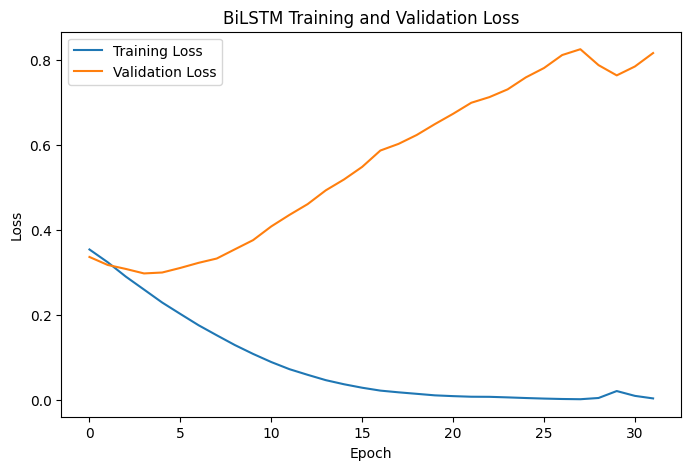

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Training and Validation Loss")

plt.legend()
plt.show()